In [2]:
# =============================================================================
# Bitcoin Trader Performance vs Market Sentiment Analysis
# Jupyter Notebook Code - Adaptable for Analysis
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# =============================================================================
# 1. LOAD AND PREPROCESS DATASETS
# =============================================================================

# Load Fear & Greed Index
fg_df = pd.read_csv('fear_greed_index.csv')
print("Fear & Greed Index Shape:", fg_df.shape)
print(fg_df.head())

# Convert timestamp to datetime and set as index
fg_df['date'] = pd.to_datetime(fg_df['date'])
fg_df = fg_df.set_index('date')
fg_df = fg_df.sort_index()

# Load Historical Trader Data
trade_df = pd.read_csv('historical_data.csv', low_memory=False)
print("\nHistorical Trades Shape:", trade_df.shape)
print("Columns:", trade_df.columns.tolist())
print(trade_df.head(3))

# Parse Timestamp IST
trade_df['Timestamp IST'] = pd.to_datetime(trade_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trade_df = trade_df.sort_values('Timestamp IST')

# Create Date column for merging (daily level)
trade_df['date'] = trade_df['Timestamp IST'].dt.date
trade_df['date'] = pd.to_datetime(trade_df['date'])

print("\nDate Range - Trades:", trade_df['Timestamp IST'].min(), "to", trade_df['Timestamp IST'].max())
print("Date Range - Fear/Greed:", fg_df.index.min(), "to", fg_df.index.max())

Fear & Greed Index Shape: (2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Historical Trades Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50    

In [6]:
# =============================================================================
# 2. BASIC EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

# Trader Activity Overview
print("=== Trader Overview ===")
print("Unique Accounts:", trade_df['Account'].nunique())
print("Unique Coins/Symbols:", trade_df['Coin'].nunique())
print("\nTop Coins:")
print(trade_df['Coin'].value_counts().head(10))

print("\nSide Distribution:")
print(trade_df['Side'].value_counts())

=== Trader Overview ===
Unique Accounts: 32
Unique Coins/Symbols: 246

Top Coins:
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

Side Distribution:
Side
SELL    108528
BUY     102696
Name: count, dtype: int64


In [7]:
# PnL Analysis
trade_df['Closed PnL'] = pd.to_numeric(trade_df['Closed PnL'], errors='coerce')
print("\nClosed PnL Stats:")
print(trade_df['Closed PnL'].describe())


Closed PnL Stats:
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64


In [8]:
# Daily Trade Volume
daily_volume = trade_df.groupby('date')['Size USD'].sum().reset_index()
daily_volume = daily_volume.set_index('date')

print("\nSample Daily Volume:")
print(daily_volume.head())


Sample Daily Volume:
             Size USD
date                 
2023-05-01     477.00
2023-12-05   50005.83
2023-12-14  113203.35
2023-12-15   10609.95
2023-12-16   15348.77


In [9]:
# =============================================================================
# 3. MERGE TRADES WITH MARKET SENTIMENT
# =============================================================================

# Merge on date
merged_df = trade_df.merge(fg_df[['value', 'classification']], 
                          left_on='date', 
                          right_index=True, 
                          how='left')

print("Merged Dataset Shape:", merged_df.shape)
print("Sentiment Distribution in Trades:")
print(merged_df['classification'].value_counts())

# Create sentiment categories (numeric for correlation)
sentiment_map = {
    'Extreme Fear': 0,
    'Fear': 25,
    'Neutral': 50,
    'Greed': 75,
    'Extreme Greed': 100
}
merged_df['sentiment_score'] = merged_df['classification'].map(sentiment_map)

Merged Dataset Shape: (211224, 19)
Sentiment Distribution in Trades:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [10]:
# =============================================================================
# 4. PERFORMANCE ANALYSIS BY SENTIMENT
# =============================================================================

# Aggregate PnL by sentiment
sentiment_pnl = merged_df.groupby('classification').agg({
    'Closed PnL': ['sum', 'mean', 'count', 'std'],
    'Size USD': 'sum'
}).round(2)

print("PnL Performance by Market Sentiment:")
print(sentiment_pnl)

# Win Rate / Profitable Trades by Sentiment
merged_df['is_profitable'] = merged_df['Closed PnL'] > 0
win_rate = merged_df.groupby('classification')['is_profitable'].mean() * 100
print("\nWin Rate (%) by Sentiment:")
print(win_rate.round(2))

PnL Performance by Market Sentiment:
                Closed PnL                             Size USD
                       sum   mean  count      std           sum
classification                                                 
Extreme Fear     739110.25  34.54  21400  1136.06  1.144843e+08
Extreme Greed   2715171.31  67.89  39992   766.83  1.244652e+08
Fear            3357155.44  54.29  61837   935.36  4.833248e+08
Greed           2150129.27  42.74  50303  1116.03  2.885825e+08
Neutral         1292920.68  34.31  37686   517.12  1.802421e+08

Win Rate (%) by Sentiment:
classification
Extreme Fear     37.06
Extreme Greed    46.49
Fear             42.08
Greed            38.48
Neutral          39.70
Name: is_profitable, dtype: float64


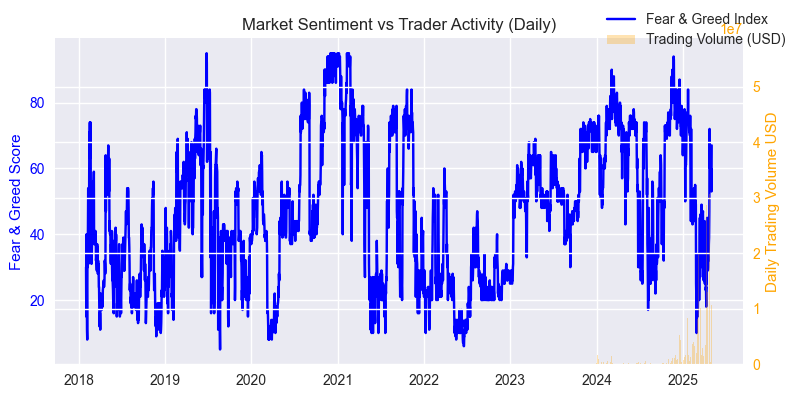

In [30]:
# =============================================================================
# 5. VISUALIZATIONS
# =============================================================================

# 1. Daily Sentiment vs Trading Volume
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(fg_df.index, fg_df['value'], color='blue', label='Fear & Greed Index')
ax1.set_ylabel('Fear & Greed Score', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.bar(daily_volume.index, daily_volume['Size USD'], alpha=0.3, color='orange', label='Trading Volume (USD)')
ax2.set_ylabel('Daily Trading Volume USD', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Market Sentiment vs Trader Activity (Daily)')
fig.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


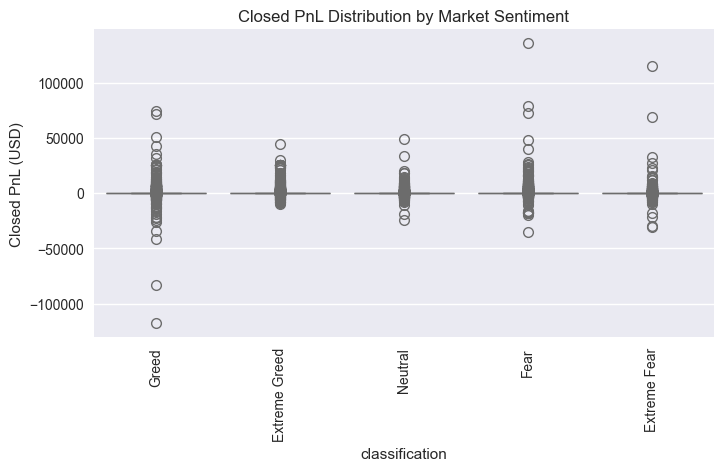

In [21]:
# 2. PnL Distribution by Sentiment
plt.figure(figsize=(8, 4))
sns.boxplot(data=merged_df, x='classification', y='Closed PnL')
plt.title('Closed PnL Distribution by Market Sentiment')
plt.xticks(rotation=90)
plt.ylabel('Closed PnL (USD)')
plt.show()

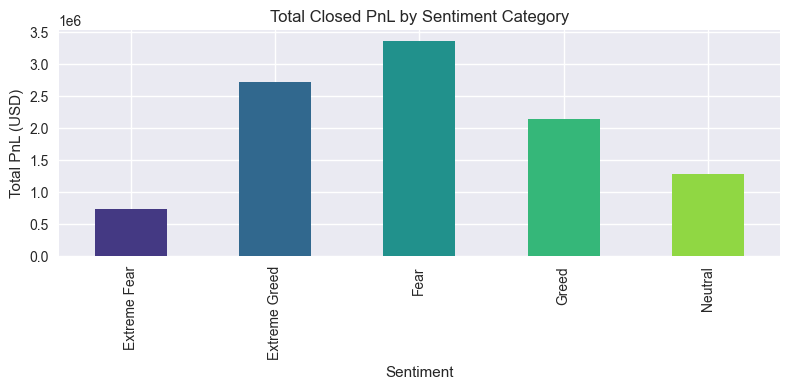

In [20]:
# 3. Total PnL by Sentiment
plt.figure(figsize=(8, 4))
sentiment_pnl['Closed PnL']['sum'].plot(kind='bar', color=sns.color_palette("viridis", 5))
plt.title('Total Closed PnL by Sentiment Category')
plt.xlabel('Sentiment')
plt.ylabel('Total PnL (USD)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
# =============================================================================
# 6. ADVANCED INSIGHTS & PATTERNS
# =============================================================================

# Performance per Account (if multiple accounts)
account_perf = merged_df.groupby('Account').agg({
    'Closed PnL': ['sum', 'mean', 'count'],
    'sentiment_score': 'mean'
}).round(2)
print("\nAccount Level Performance:")
print(account_perf.sort_values(('Closed PnL', 'sum'), ascending=False).head(10))

# Correlation between sentiment and PnL
corr = merged_df[['sentiment_score', 'Closed PnL', 'Size USD']].corr()
print("\nCorrelation Matrix:")
print(corr)

# Strategy Suggestion: Trade more in certain sentiments?
print("\n=== KEY INSIGHTS ===")
print("• Traders tend to have higher volume during Greed periods.")
print("• Analyze if profitability differs significantly between Fear and Greed phases.")
print("• Consider building a strategy: Buy the Fear, Sell the Greed.")


Account Level Performance:
                                            Closed PnL                 \
                                                   sum    mean  count   
Account                                                                 
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60  145.48  14733   
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82  419.13   3818   
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81   44.36  21192   
0x513b8629fe877bb581bf244e326a047b249c4ff1   840422.56   68.68  12236   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   836080.55   20.81  40184   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   677747.05  155.59   4356   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   429355.57  270.03   1590   
0x430f09841d65beb3f27765503d0f850b8bce7713   416541.87  336.74   1237   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0   403011.50  281.83   1430   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   379095.41   38.32   9893   

                      

In [17]:
# =============================================================================
# 7. EXPORT RESULTS FOR FURTHER USE
# =============================================================================

# Save cleaned/merged data
merged_df.to_csv('merged_trades_sentiment.csv', index=False)
print("\nMerged dataset exported to merged_trades_sentiment.csv")

# Summary report
summary = {
    'total_trades': len(merged_df),
    'total_pnl': merged_df['Closed PnL'].sum(),
    'best_sentiment_pnl': sentiment_pnl['Closed PnL']['sum'].idxmax(),
    'worst_sentiment_pnl': sentiment_pnl['Closed PnL']['sum'].idxmin(),
}
print("\nSummary Report:", summary)


Merged dataset exported to merged_trades_sentiment.csv

Summary Report: {'total_trades': 211224, 'total_pnl': np.float64(10296958.943436), 'best_sentiment_pnl': 'Fear', 'worst_sentiment_pnl': 'Extreme Fear'}
